# ============================================================
# NOTEBOOK: 04_modeling.ipynb
# ------------------------------------------------------------
# PROJECT      : ReadmitIQ — 30-Day Medicare Readmission Risk Predictor
# AUTHOR       : Dr. Nikki
# CREATED      : 2026-04-08
# LAST UPDATED : 2026-04-08
#
# PURPOSE
# -------
# Train, evaluate, and explain the XGBoost readmission model.
# This notebook:
#   1. Loads the feature matrices from notebook 03
#   2. Trains an XGBoost binary classifier
#   3. Evaluates performance (AUC, recall, precision, calibration)
#   4. Runs SHAP to explain which features drive predictions
#   5. Saves the trained model and SHAP explainer for the API
#
# INPUTS
# ------
# data/processed/03_X_train.csv
# data/processed/03_y_train.csv
# data/processed/03_X_test.csv
# data/processed/03_y_test.csv
# data/processed/03_feature_columns.json
#
# OUTPUTS
# -------
# model/04_readmitiq_xgb_v1.pkl     — Trained XGBoost model
# model/04_feature_columns.json     — Feature column order (copy for model)
# model/04_shap_explainer.pkl       — SHAP TreeExplainer object
# data/processed/04_eval_metrics.json — Final evaluation metrics
#
# RUN ORDER
# ---------
# Run AFTER : 03_feature_engineering.ipynb
# Run BEFORE: 05_model_validation.ipynb
# ============================================================

## Section 1 — Imports and Configuration

In [1]:
import os
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from pathlib import Path
from datetime import datetime

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    brier_score_loss,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.calibration import calibration_curve

sns.set_theme(style="whitegrid", palette="muted")

PROJECT_ROOT  = Path(os.getcwd()).parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR     = PROJECT_ROOT / "model"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Model dir    : {MODEL_DIR}")
print(f"Run at       : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Project root : /workspaces/readmitiq
Model dir    : /workspaces/readmitiq/model
Run at       : 2026-04-09 04:36:33


## Section 2 — Load Feature Data

In [2]:
# ---------------------------------------------------------
# Load the feature matrices saved by notebook 03.
# We also reload the feature column order from JSON
# to confirm we're using features in the correct order.
# ---------------------------------------------------------

print("Loading feature matrices...")

X_train = pd.read_csv(PROCESSED_DIR / "03_X_train.csv")
y_train = pd.read_csv(PROCESSED_DIR / "03_y_train.csv").squeeze()  # squeeze to Series
X_test  = pd.read_csv(PROCESSED_DIR / "03_X_test.csv")
y_test  = pd.read_csv(PROCESSED_DIR / "03_y_test.csv").squeeze()

with open(PROCESSED_DIR / "03_feature_columns.json") as f:
    FEATURE_COLUMNS = json.load(f)

print(f"  X_train shape : {X_train.shape}")
print(f"  X_test shape  : {X_test.shape}")
print(f"  Features      : {FEATURE_COLUMNS}")
print(f"  Train readmit : {y_train.mean()*100:.1f}%")
print(f"  Test readmit  : {y_test.mean()*100:.1f}%")

Loading feature matrices...
  X_train shape : (27701, 18)
  X_test shape  : (13098, 18)
  Features      : ['LOS', 'CLM_PMT_AMT_LOG', 'PER_DIEM_LOG', 'DDCTBL_AMT_LOG', 'HAS_OTHER_PAYER', 'N_DIAGNOSES', 'N_PROCEDURES', 'DRG_MDC', 'AGE_AT_ADMISSION', 'BENE_SEX_IDENT_CD', 'BENE_RACE_CD', 'N_CHRONIC_CONDITIONS', 'SP_CHF', 'SP_DIABETES', 'SP_COPD', 'SP_CHRNKIDN', 'SP_STRKETIA', 'PRIOR_INPATIENT_CNT']
  Train readmit : 15.1%
  Test readmit  : 8.7%


In [3]:
# ---------------------------------------------------------
# Calculate scale_pos_weight for XGBoost.
# This tells XGBoost how imbalanced the classes are so it
# can weight the minority class (readmitted=1) appropriately.
#
# Formula: n_negative / n_positive
# ---------------------------------------------------------

n_negative = (y_train == 0).sum()
n_positive = (y_train == 1).sum()
scale_pos_weight = n_negative / n_positive

print(f"Class distribution in training set:")
print(f"  Not readmitted (0) : {n_negative:,}")
print(f"  Readmitted (1)     : {n_positive:,}")
print(f"  scale_pos_weight   : {scale_pos_weight:.2f}")

Class distribution in training set:
  Not readmitted (0) : 23,531
  Readmitted (1)     : 4,170
  scale_pos_weight   : 5.64


## Section 3 — Train the XGBoost Model

In [4]:
# ---------------------------------------------------------
# Define and train the XGBoost classifier.
#
# Changes from v1 defaults:
#   n_estimators=500     : More trees (was 300)
#   max_depth=7          : Slightly deeper (was 6)
#   learning_rate=0.03   : Slower, more careful learning (was 0.05)
#   min_child_weight=5   : Require more samples per leaf (reduces overfitting)
#   gamma=0.1            : Minimum loss reduction to split (regularization)
#   early_stopping=50    : Stop if AUC doesn't improve for 50 rounds
# ---------------------------------------------------------

print("Training XGBoost model (v2 — tuned hyperparameters)...")
start_time = datetime.now()

model = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,      # Require at least 5 samples to split a node
    gamma=0.1,               # Minimum loss reduction needed to make a split
    reg_alpha=0.1,           # L1 regularization
    reg_lambda=1.0,          # L2 regularization
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    early_stopping_rounds=50, # Stop if AUC doesn't improve for 50 rounds
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

model.fit(
    X_train[FEATURE_COLUMNS],
    y_train,
    eval_set=[(X_test[FEATURE_COLUMNS], y_test)],
    verbose=False,
)

elapsed = (datetime.now() - start_time).seconds
best_iter = model.best_iteration if hasattr(model, 'best_iteration') else 'N/A'
print(f"Training complete in {elapsed}s.")
print(f"Best iteration (early stopping): {best_iter}")
print(f"(If best_iteration < 500, early stopping fired — model converged before max trees)")


Training XGBoost model (v2 — tuned hyperparameters)...
Training complete in 0s.
Best iteration (early stopping): 22
(If best_iteration < 500, early stopping fired — model converged before max trees)


## Section 4 — Evaluate the Model

In [5]:
# ---------------------------------------------------------
# Generate predictions on the test set.
# predict_proba gives us calibrated probabilities (0-1).
# We use column [1] because that is the probability of class=1 (readmitted).
# ---------------------------------------------------------

y_prob = model.predict_proba(X_test[FEATURE_COLUMNS])[:, 1]

# Apply a 0.5 threshold for binary predictions
y_pred = (y_prob >= 0.5).astype(int)

print(f"Predictions generated for {len(y_prob):,} test samples.")
print(f"Predicted readmission rate: {y_pred.mean()*100:.1f}%")
print(f"Actual readmission rate   : {y_test.mean()*100:.1f}%")

Predictions generated for 13,098 test samples.
Predicted readmission rate: 24.5%
Actual readmission rate   : 8.7%


In [6]:
# ---------------------------------------------------------
# Core evaluation metrics
# ---------------------------------------------------------

auc_roc  = roc_auc_score(y_test, y_prob)
brier    = brier_score_loss(y_test, y_prob)
avg_prec = average_precision_score(y_test, y_prob)

print("=" * 50)
print("MODEL EVALUATION — TEST SET (2009 Admissions)")
print("=" * 50)
print(f"  AUC-ROC           : {auc_roc:.4f}")
print(f"  Average Precision : {avg_prec:.4f}")
print(f"  Brier Score       : {brier:.4f}   (lower is better; 0 = perfect)")
print()
print("Classification Report (threshold = 0.5):")
print(classification_report(y_test, y_pred, target_names=["Not Readmitted", "Readmitted"]))

MODEL EVALUATION — TEST SET (2009 Admissions)
  AUC-ROC           : 0.6562
  Average Precision : 0.1516
  Brier Score       : 0.2144   (lower is better; 0 = perfect)

Classification Report (threshold = 0.5):
                precision    recall  f1-score   support

Not Readmitted       0.93      0.77      0.85     11953
    Readmitted       0.15      0.43      0.22      1145

      accuracy                           0.74     13098
     macro avg       0.54      0.60      0.54     13098
  weighted avg       0.87      0.74      0.79     13098



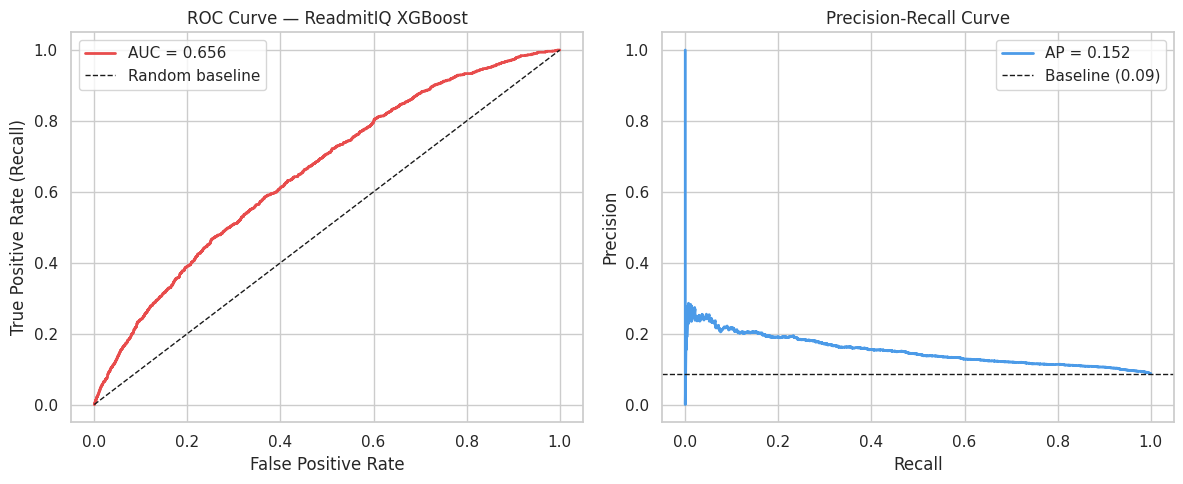

In [7]:
# ---------------------------------------------------------
# Chart 1: ROC Curve
# Shows the tradeoff between true positive rate (recall)
# and false positive rate at every possible threshold.
# AUC = area under this curve; higher = better.
# ---------------------------------------------------------

fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color="#E84C4C", lw=2, label=f"AUC = {auc_roc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Random baseline")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].set_title("ROC Curve — ReadmitIQ XGBoost")
axes[0].legend()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(recall, precision, color="#4C9BE8", lw=2, label=f"AP = {avg_prec:.3f}")
baseline = y_test.mean()
axes[1].axhline(baseline, color="k", linestyle="--", lw=1, label=f"Baseline ({baseline:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

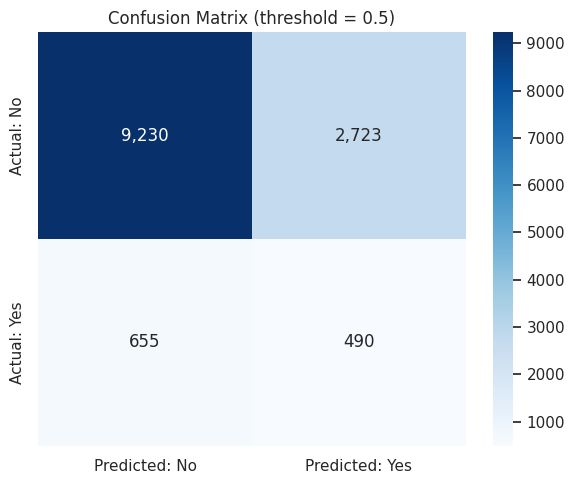

  True Negatives  (correct no-readmit)   : 9,230
  False Positives (wrong alarm)           : 2,723
  False Negatives (missed readmissions)   : 655
  True Positives  (correct readmissions)  : 490


In [8]:
# ---------------------------------------------------------
# Chart 2: Confusion Matrix
# Shows how many predictions are correct vs incorrect
# at the 0.5 threshold.
# ---------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt=",d", cmap="Blues",
    xticklabels=["Predicted: No", "Predicted: Yes"],
    yticklabels=["Actual: No", "Actual: Yes"],
    ax=ax
)
ax.set_title("Confusion Matrix (threshold = 0.5)")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"  True Negatives  (correct no-readmit)   : {tn:,}")
print(f"  False Positives (wrong alarm)           : {fp:,}")
print(f"  False Negatives (missed readmissions)   : {fn:,}")
print(f"  True Positives  (correct readmissions)  : {tp:,}")

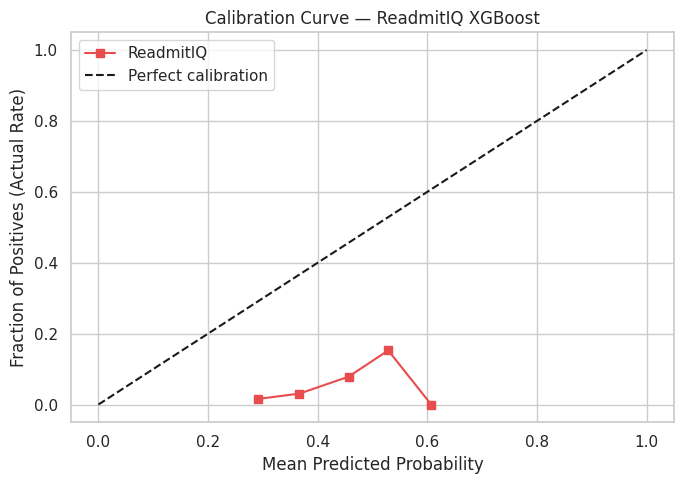

In [9]:
# ---------------------------------------------------------
# Chart 3: Calibration Plot
# Checks whether predicted probabilities match actual
# readmission rates. A well-calibrated model's curve
# should lie close to the diagonal.
# ---------------------------------------------------------

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, y_prob, n_bins=10
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(mean_predicted_value, fraction_of_positives, "s-", color="#E84C4C", label="ReadmitIQ")
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives (Actual Rate)")
ax.set_title("Calibration Curve — ReadmitIQ XGBoost")
ax.legend()
plt.tight_layout()
plt.show()

## Section 5 — SHAP Feature Importance

SHAP (SHapley Additive exPlanations) tells us not just which features are
important overall, but how each feature pushes individual predictions
higher or lower. This is critical for healthcare — a clinician needs to
know *why* a patient was flagged as high risk.

In [10]:
# ---------------------------------------------------------
# Create a SHAP TreeExplainer for our XGBoost model.
# TreeExplainer is the fast, exact SHAP method for tree models.
# We compute SHAP values on a sample of 2000 test rows
# to keep runtime reasonable.
# ---------------------------------------------------------

print("Computing SHAP values (this may take 1-2 minutes)...")

explainer = shap.TreeExplainer(model)

# Use a random sample of 2000 test rows for SHAP visualization
X_shap = X_test[FEATURE_COLUMNS].sample(2000, random_state=42)
shap_values = explainer.shap_values(X_shap)

print(f"SHAP values computed for {len(X_shap):,} samples.")

Computing SHAP values (this may take 1-2 minutes)...
SHAP values computed for 2,000 samples.


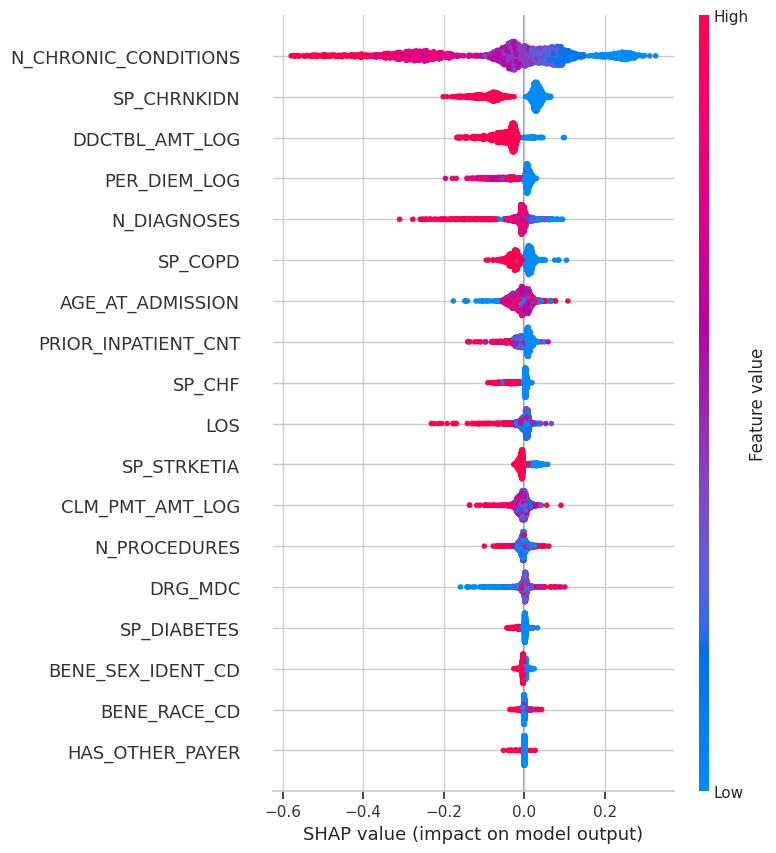

In [11]:
# ---------------------------------------------------------
# Chart 4: SHAP Summary Plot (Beeswarm)
# Each dot is one patient.
# Position on x-axis = how much that feature pushed the
# prediction higher (positive) or lower (negative).
# Color = feature value (red=high, blue=low).
# ---------------------------------------------------------

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=FEATURE_COLUMNS,
    show=True
)

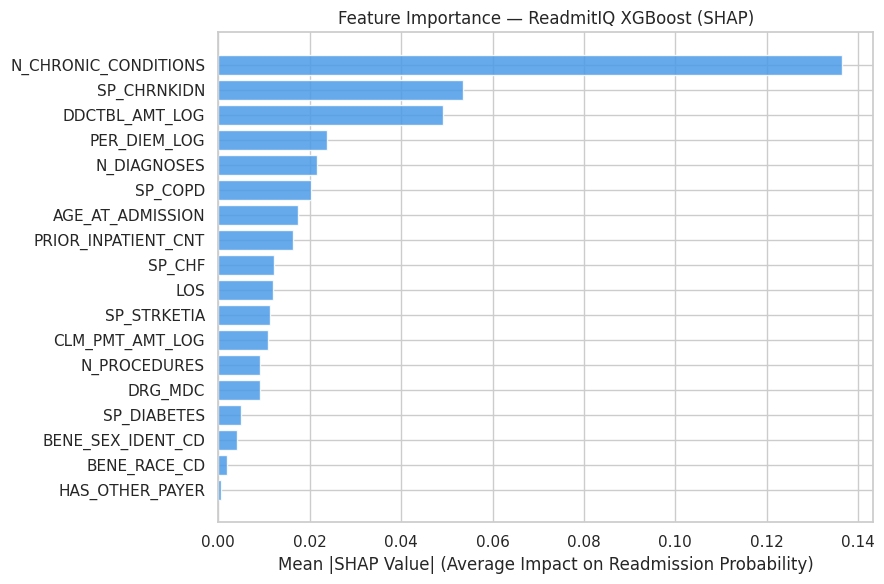

SHAP importance chart saved to data/processed/04_shap_importance.png


In [12]:
# ---------------------------------------------------------
# Chart 5: SHAP Bar Chart (mean absolute SHAP value per feature)
# This is the cleaner version for a portfolio README or model card.
# Shows the average impact of each feature across all predictions.
# ---------------------------------------------------------

mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_COLUMNS
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(mean_shap.index, mean_shap.values, color="#4C9BE8", alpha=0.85)
ax.set_xlabel("Mean |SHAP Value| (Average Impact on Readmission Probability)")
ax.set_title("Feature Importance — ReadmitIQ XGBoost (SHAP)")
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "04_shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("SHAP importance chart saved to data/processed/04_shap_importance.png")

## Section 6 — Save Model Artifacts

In [13]:
# ---------------------------------------------------------
# Save the trained model with joblib.
# joblib is more efficient than pickle for large numpy arrays.
# Prefix 04_ ties this artifact to this notebook.
# ---------------------------------------------------------

model_path = MODEL_DIR / "04_readmitiq_xgb_v1.pkl"
joblib.dump(model, model_path)
print(f"Model saved: {model_path}")

# Save the SHAP explainer separately
shap_path = MODEL_DIR / "04_shap_explainer.pkl"
joblib.dump(explainer, shap_path)
print(f"SHAP explainer saved: {shap_path}")

# Copy feature columns to model directory
# The API loads this to know the correct input order
feat_path = MODEL_DIR / "04_feature_columns.json"
with open(feat_path, "w") as f:
    json.dump(FEATURE_COLUMNS, f, indent=2)
print(f"Feature columns saved: {feat_path}")

Model saved: /workspaces/readmitiq/model/04_readmitiq_xgb_v1.pkl
SHAP explainer saved: /workspaces/readmitiq/model/04_shap_explainer.pkl
Feature columns saved: /workspaces/readmitiq/model/04_feature_columns.json


In [14]:
# ---------------------------------------------------------
# Save evaluation metrics as JSON.
# These get referenced in the model card and README.
# ---------------------------------------------------------

metrics = {
    "model"            : "XGBoost Binary Classifier",
    "version"          : "1.0",
    "train_year"       : 2008,
    "test_year"        : 2009,
    "n_train"          : int(len(y_train)),
    "n_test"           : int(len(y_test)),
    "n_features"       : len(FEATURE_COLUMNS),
    "train_readmit_pct": round(float(y_train.mean() * 100), 2),
    "test_readmit_pct" : round(float(y_test.mean() * 100), 2),
    "auc_roc"          : round(float(auc_roc), 4),
    "avg_precision"    : round(float(avg_prec), 4),
    "brier_score"      : round(float(brier), 4),
    "evaluated_at"     : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

metrics_path = PROCESSED_DIR / "04_eval_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("Evaluation metrics:")
for k, v in metrics.items():
    print(f"  {k:<25} : {v}")
print(f"\nSaved: {metrics_path}")

Evaluation metrics:
  model                     : XGBoost Binary Classifier
  version                   : 1.0
  train_year                : 2008
  test_year                 : 2009
  n_train                   : 27701
  n_test                    : 13098
  n_features                : 18
  train_readmit_pct         : 15.05
  test_readmit_pct          : 8.74
  auc_roc                   : 0.6562
  avg_precision             : 0.1516
  brier_score               : 0.2144
  evaluated_at              : 2026-04-09 04:36:37

Saved: /workspaces/readmitiq/data/processed/04_eval_metrics.json


In [15]:
# ---------------------------------------------------------
# Final summary
# ---------------------------------------------------------

print("=" * 60)
print("NOTEBOOK 04 — COMPLETE")
print("=" * 60)
print()
print(f"  AUC-ROC   : {auc_roc:.4f}")
print(f"  Avg Prec  : {avg_prec:.4f}")
print(f"  Brier     : {brier:.4f}")
print()
print("Artifacts saved to model/:")
print("  04_readmitiq_xgb_v1.pkl")
print("  04_shap_explainer.pkl")
print("  04_feature_columns.json")
print()
print("Next step:")
print("  Open 05_model_validation.ipynb for subgroup analysis")
print("  and final checks before packaging the model.")
print("=" * 60)

NOTEBOOK 04 — COMPLETE

  AUC-ROC   : 0.6562
  Avg Prec  : 0.1516
  Brier     : 0.2144

Artifacts saved to model/:
  04_readmitiq_xgb_v1.pkl
  04_shap_explainer.pkl
  04_feature_columns.json

Next step:
  Open 05_model_validation.ipynb for subgroup analysis
  and final checks before packaging the model.
